Purpose: Perform a high-frequency parameter optimization for the Indicator-Based strategy.

Data Source: Parquet format for optimized loading.

Logic: Uses the generate_actions API with the "Predictability Guardrails" (Min Profit, ADX, and ATR floors) to find a stable baseline for future ML modeling.

In [7]:
%matplotlib inline 

# 1) Wipe out your namespace
%reset -f

# 2) Clear Jupyter’s stored outputs and inputs 
try:
    Out.clear() 
    In.clear()
except NameError:
    pass

# 3) Force Python GC
import gc
gc.collect()

# 4) Free any GPU buffers
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Core Library Imports
import importlib
from libs import params, feats, strats, opts, models_core
importlib.reload(params)
importlib.reload(feats)
importlib.reload(strats)
importlib.reload(opts)
importlib.reload(models_core)

# Standard Data Science Stack
import numpy as np
import pandas as pd
import math
import time
import datetime as dt
from datetime import datetime, time as dt_time
from pathlib import Path

# UI and Progress
from tqdm import tqdm
from IPython.display import clear_output, display

# Plotting Configuration
import matplotlib.pyplot as plt
import seaborn as sns
plt.ioff() # Turn off interactive plotting

# Optimization Stack
import optuna
from optuna.samplers import TPESampler

# Ensure Dataset compatibility for pickling/loading
torch.serialization.add_safe_globals([models_core.DayWindowDataset])

pd.set_option('display.max_columns', None)


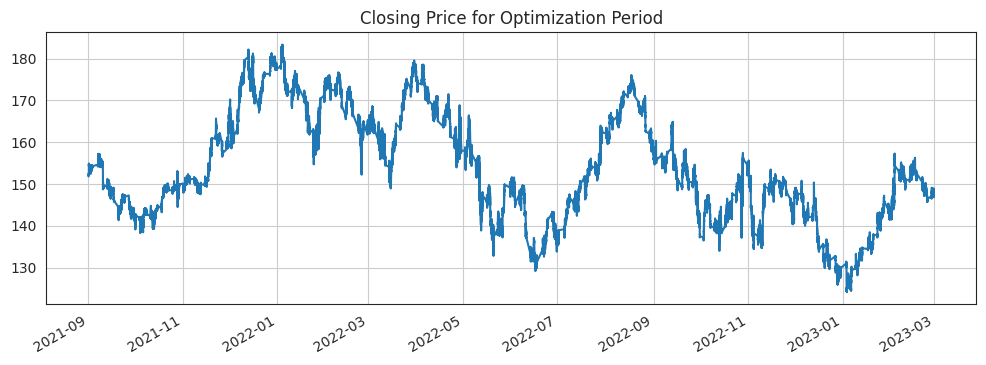

,open,high,low,close,volume,trade_count,vwap,ask,bid,ret,log_ret,sma_5,sma_pct_5,sma_9,sma_pct_9,sma_21,sma_pct_21,sma_50,sma_pct_50,sma_100,sma_pct_100,ema_5,ema_9,ema_13,ema_21,ema_50,roc_5,roc_10,roc_21,body,body_pct,upper_shad,lower_shad,range_pct,rsi_7,rsi_14,rsi_21,rsi_28,macd_line_6_13_5,macd_signal_6_13_5,macd_diff_6_13_5,macd_line_12_26_9,macd_signal_12_26_9,macd_diff_12_26_9,atr_7,atr_pct_7,atr_14,atr_pct_14,atr_21,atr_pct_21,atr_28,atr_pct_28,plus_di_7,minus_di_7,adx_7,plus_di_14,minus_di_14,adx_14,plus_di_21,minus_di_21,adx_21,plus_di_28,minus_di_28,adx_28,bb_lband_20_2p0,bb_hband_20_2p0,bb_w_20_2p0,bb_lband_20_3p0,bb_hband_20_3p0,bb_w_20_3p0,bb_lband_50_2p0,bb_hband_50_2p0,bb_w_50_2p0,obv,vol_spike_7,vol_spike_14,vol_spike_28,rolling_max_close_100,rolling_min_close_100,dist_high_100,dist_low_100,obv_diff_7,obv_pct_7,obv_diff_21,obv_pct_21,ret_std_21,ret_std_63,stoch_k_14_3_3,stoch_d_14_3_3,stoch_k_9_3_3,stoch_d_9_3_3,cci_14,cci_20,mfi_14,mfi_20,cmf_14,cmf_20,donch_h_20,donch_l_20,donch_w_20,donch_h_55,donch_l_55,donch_w_55,roll_vwap_20,roll_vwap_50,slope_close_20,slope_close_50,kc_mid_20_20_1.5,kc_l_20_20_1.5,kc_h_20_20_1.5,kc_w_20_20_1.5,kc_mid_20_20_2.0,kc_l_20_20_2.0,kc_h_20_20_2.0,kc_w_20_20_2.0,vwap_ohlc_close_session
2021-09-01 07:00:00,152.340,152.400,152.200,152.310,2052.0,79.0,152.343289,152.3405,152.2795,0.002633,0.002630,151.956,0.002330,151.911111,0.002626,151.874286,0.002869,151.8499,0.003030,151.862702,0.002945,152.018578,151.953148,151.923549,151.894996,151.867887,0.002963,0.003095,0.003161,-0.03,-0.000197,0.06,0.11,0.001313,96.377536,92.108647,88.907688,86.258175,0.072060,0.027698,0.044362,0.043925,0.012360,0.031565,0.093550,0.000614,0.053679,0.000352,0.039270,0.000258,0.031763,0.000209,84.467536,3.401602,28.421520,77.491111,7.239535,19.072892,73.251549,9.807319,15.994430,69.968105,11.638923,14.391505,151.674268,152.077732,0.002657,151.573401,152.178599,0.003985,151.714905,151.984895,0.001778,1.529217e+10,0.613270,1.023843,1.224605,152.40,151.80,0.000591,0.003348,19082.0,125.599677,27680.000000,182.256001,0.000579,0.000339,0.948276,0.871648,0.948276,0.816092,466.666667,500.000000,85.708219,81.744827,0.262026,0.233686,152.400000,151.82,0.003808,152.400,151.80,0.003939,151.889248,151.866828,0.007699,0.001677,151.897444,151.836322,151.958567,0.000805,151.897444,151.815948,151.978941,0.001073,152.310000
2021-09-01 07:01:00,152.310,152.310,152.310,152.310,1163.0,12.0,152.310000,152.3405,152.2795,0.000000,0.000000,152.048,0.001723,151.961111,0.002296,151.896667,0.002721,151.8593,0.002968,151.866702,0.002919,152.115719,152.024518,151.978756,151.932724,151.885225,0.003029,0.003095,0.003095,0.00,0.000000,0.00,0.00,0.000000,96.377536,92.108647,88.907688,86.258175,0.106679,0.054025,0.052654,0.071035,0.024095,0.046941,0.080186,0.000526,0.049844,0.000327,0.037400,0.000246,0.030628,0.000201,84.467536,3.401602,37.540956,77.491111,7.239535,23.632803,73.251549,9.807319,18.870155,69.968105,11.638923,16.430226,151.624973,152.175027,0.003621,151.487459,152.312541,0.005432,151.672758,152.045842,0.002457,1.529217e+10,0.376288,0.576864,0.696184,152.40,151.80,0.000591,0.003348,17295.0,113.788242,26841.000000,176.705655,0.000579,0.000339,0.896552,0.911239,0.896552,0.892720,235.338654,336.051648,85.801987,86.061612,0.295809,0.278437,152.400000,151.82,0.003808,152.400,151.80,0.003939,151.905092,151.875656,0.013173,0.002735,151.936735,151.878669,151.994802,0.000764,151.936735,151.859314,152.014157,0.001019,152.310000
2021-09-01 07:02:00,152.300,152.300,152.300,152.300,900.0,32.5,152.300000,152.3305,152.2695,-0.000066,-0.000066,152.138,0.001065,152.011111,0.001900,151.919048,0.002508,151.8687,0.002840,151.870602,0.002827,152.177146,152.079614,152.024648,151.966113,151.901491,0.002963,0.002897,0.003096,0.00,0.000000,0.00,0.00,0.000000,93.752280,90.188784,87.281932,84.819014,0.122091,0.076714,0.045377,0.090669,0.037410,0.053259,0.070159,0.000461,0.046998,0.000309,0.036095,0.000237,0.029892,0.000196,82.747626,5.368519,44.722948,7

In [8]:
# Load the data
df_inds = pd.read_parquet(params.indunsc_parquet)

# Ensure it's sorted by index (time)
df_inds.sort_index(inplace=True)

# Apply date slice
df_inds = df_inds[(df_inds.index >= params.start_date_sim) & (df_inds.index < params.end_date_sim)]

# Visual Verification
plt.figure(figsize=(12, 4))
df_inds.close.plot(title="Closing Price for Optimization Period")
plt.grid(True)
plt.show()

df_inds

In [9]:
# {'min_prof_thr': (0.37448200505963763, 0.4043479949403624),
#  'max_down_prop': (0.8174029683588455, 0.8953570316411543),
#  'gain_tightfact': (7.442749955358545, 8.293230044641454),
#  'tau_time': (2.5249753668358856, 44.15044463316411),
#  'tau_dur': (169.3727599303279, 180.29370006967213),
#  'rsi_min_thresh': (49.10446724535535, 49.550462754644656),
#  'rsi_max_thresh': (58.31378175908279, 58.372428240917216),
#  'adx_thresh': (27.548422338796748, 27.61325766120325),
#  'atr_mult': (7.7515725840324885, 8.16652741596751),
#  'vwap_atr_mult': (1.1432809291101353, 1.244709070889865),
#  'buy_factor': (2.831942700926633, 3.995247299073367),
#  'sell_factor': (5.751983182400653, 6.199176817599347),
#  'trailstop_pct': (2.510186983354566, 3.116713016645434),
#  'sign_thresh_pair': {'categorical': ['cci_20|0.0']}}

{'min_prof_thr': (0.37448200505963763, 0.4043479949403624),
 'max_down_prop': (0.8174029683588455, 0.8953570316411543),
 'gain_tightfact': (7.442749955358545, 8.293230044641454),
 'tau_time': (2.5249753668358856, 44.15044463316411),
 'tau_dur': (169.3727599303279, 180.29370006967213),
 'rsi_min_thresh': (49.10446724535535, 49.550462754644656),
 'rsi_max_thresh': (58.31378175908279, 58.372428240917216),
 'adx_thresh': (27.548422338796748, 27.61325766120325),
 'atr_mult': (7.7515725840324885, 8.16652741596751),
 'vwap_atr_mult': (1.1432809291101353, 1.244709070889865),
 'buy_factor': (2.831942700926633, 3.995247299073367),
 'sell_factor': (5.751983182400653, 6.199176817599347),
 'trailstop_pct': (2.510186983354566, 3.116713016645434),
 'sign_thresh_pair': {'categorical': ['cci_20|0.0']}}

In [10]:
def objective(trial: optuna.Trial) -> float:
    # --- 1. Parameters (Predictability Floors applied) ---
    min_prof_thr    = trial.suggest_float("min_prof_thr", 0.37, 0.41)      # STRICT FLOOR: 0.05
    max_down_prop   = trial.suggest_float("max_down_prop", 0.8, 0.9)      
    gain_tightfact  = trial.suggest_float("gain_tightfact", 7.4, 8.3)    
    tau_time        = trial.suggest_float("tau_time", 2.0, 45.0)
    tau_dur         = trial.suggest_float("tau_dur", 169.0, 181.0)

    rsi_min_thresh  = trial.suggest_float("rsi_min_thresh", 49.0, 49.7)
    rsi_max_thresh  = trial.suggest_float("rsi_max_thresh", 58.0, 58.5)
    adx_thresh      = trial.suggest_float("adx_thresh", 27.4, 27.7)       # STRICT FLOOR: 15.0
    atr_mult        = trial.suggest_float("atr_mult", 7.6, 8.2)           # STRICT FLOOR: 1.0
    vwap_atr_mult   = trial.suggest_float("vwap_atr_mult", 1.1, 1.3)
    buy_factor      = trial.suggest_float("buy_factor", 2.8, 4.0)
    sell_factor     = trial.suggest_float("sell_factor", 5.7, 6.2)
    trailstop_pct   = trial.suggest_float("trailstop_pct", 2.5, 3.2)

    # --- 2. Signal/Threshold Combinations (Raw Indicators) ---
    sign_thresh_pair = trial.suggest_categorical("sign_thresh_pair", [ 
        # "ema_5|ema_13",           # EMA Crossover
        # "ema_9|ema_21",           # EMA Crossover
        # "macd_line_12_26_9|0.0",  # MACD Baseline cross
        # "macd_diff_6_13_5|0.0",   # MACD Histogram cross
        # "rsi_14|50.0",            # RSI Neutral cross
        # "roc_10|0.0",             # Rate of Change cross
        "cci_20|0.0",             # CCI Baseline cross
        # "mfi_14|50.0",            # Money Flow cross
        # "slope_close_20|0.0"      # Linear Regression Slope cross
    ])
    
    col_signal, sign_thresh = sign_thresh_pair.split("|")
    try: 
        sign_thresh = float(sign_thresh) # Handles "0.0", "50.0"
    except ValueError:
        pass # Handles "ema_13", "ema_21"
    
    print('-' * 160)
    print("Params => " + "; ".join(f"{k}={v}" for k, v in dict(trial.params).items()))

    # Reset globals before each simulation
    start_ask = df_inds.loc[df_inds.index.normalize() == df_inds.index.normalize().min(), "ask"].iat[0]
    strats.reset_globals(start_ask) 

    groups = list(df_inds.groupby(df_inds.index.normalize()))
    pbar = tqdm(groups, total=len(groups), desc=f"Trial {trial.number}", leave=True)
    acc = opts.TrialAccumulator(trial, pbar, report_interval=report_interval, prun_perc=prun_perc)
    
    for step, (day, df_day) in enumerate(pbar, 1):
        # generate_actions handles the weights internally using the factors
        df_actions = strats.generate_actions(
            df              = df_day,
            col_atr         = "atr_21",          
            col_adx         = "adx_21",          
            col_rsi         = "rsi_21",         
            col_vwap        = "vwap_ohlc_close_session",
            col_signal      = col_signal,
            sign_thresh     = sign_thresh,
            rsi_min_thresh  = rsi_min_thresh,
            rsi_max_thresh  = rsi_max_thresh,
            adx_thresh      = adx_thresh,
            atr_mult        = atr_mult,
            vwap_atr_mult   = vwap_atr_mult,
            trailstop_pct   = trailstop_pct,
            buy_factor      = buy_factor,
            sell_factor     = sell_factor
        )

        sim_results = strats.simulate_trading(
            day             = day,
            df              = df_actions
        )
   
        acc.process(sim_results, step, parse_eq_value_callable=strats._parse_eq_value)
        del df_actions, sim_results

    gc.collect()
    return acc.finalize()


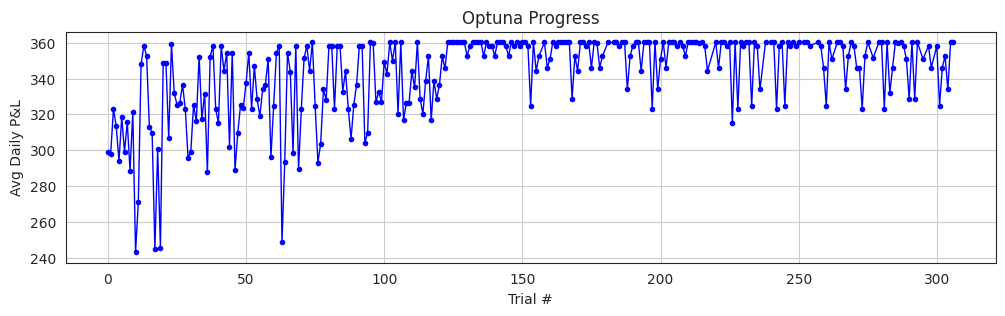

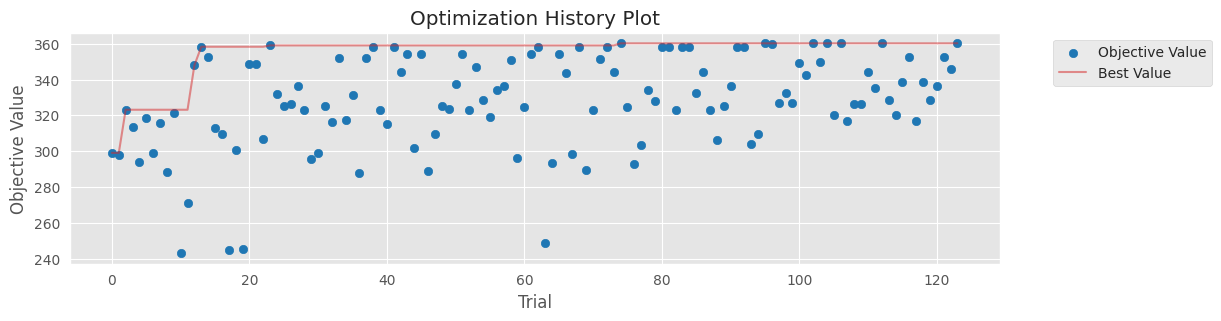

----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.3746096651720997; max_down_prop=0.8844838099536756; gain_tightfact=7.613324475033602; tau_time=39.41824311968925; tau_dur=170.9747445795034; rsi_min_thresh=49.05155375406928; rsi_max_thresh=58.45593850662298; adx_thresh=27.655708172034252; atr_mult=7.748998333588952; vwap_atr_mult=1.1897357982734158; buy_factor=3.344109351110029; sell_factor=6.05678682465427; trailstop_pct=3.1469943321400944; sign_thresh_pair=cci_20|0.0


Trial 0: 100%|██████████| 375/375 [00:19<00:00, 19.35it/s]


[Results] mean_pnl:290.2692 mean_bh:-8.7491 mean_excess:299.0183 improv_vs_bh:3417.71%
Action counts: {'Buy': 63, 'Sell': 62, 'Hold': 350586}
Best trial is: 0 with best_val: 299.0183
[save_results] wrote optuna_results/AAPL_299.0183_pred_IND.csv
[save_best_json] wrote optuna_results/AAPL_299.0183_pred_IND.json
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.40719928506047887; max_down_prop=0.8809222710128071; gain_tightfact=7.771343101007563; tau_time=30.93177649367003; tau_dur=172.85910742210015; rsi_min_thresh=49.17071576572484; rsi_max_thresh=58.4483508104416; adx_thresh=27.608677545650117; atr_mult=7.891033042512033; vwap_atr_mult=1.1734761902952433; buy_factor=3.384075631954691; sell_factor=5.700848320730267; trailstop_pct=2.827879168310467; sign_thresh_pair=cci_20|0.0


Trial 1: 100%|██████████| 375/375 [00:18<00:00, 19.88it/s]


[Results] mean_pnl:289.1169 mean_bh:-8.7491 mean_excess:297.8660 improv_vs_bh:3404.54%
Action counts: {'Buy': 64, 'Sell': 63, 'Hold': 350584}
Best trial is: 0 with best_val: 299.0183
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.3736785995977832; max_down_prop=0.895970012186188; gain_tightfact=7.734366529628293; tau_time=3.973381811068355; tau_dur=169.42823991354476; rsi_min_thresh=49.37586421513489; rsi_max_thresh=58.41168702125664; adx_thresh=27.58598982327155; atr_mult=7.754229024534456; vwap_atr_mult=1.2158540500426744; buy_factor=3.620864460443218; sell_factor=6.096081945870903; trailstop_pct=2.613763879707202; sign_thresh_pair=cci_20|0.0


...

[Results] mean_pnl:351.4693 mean_bh:-8.7491 mean_excess:360.2183 improv_vs_bh:4117.21%
Action counts: {'Buy': 67, 'Sell': 65, 'Hold': 350579}
Best trial is: 123 with best_val: 360.2753
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.38069739373228795; max_down_prop=0.8624882393313028; gain_tightfact=7.5314660825313515; tau_time=37.43032585824265; tau_dur=174.3157922394005; rsi_min_thresh=49.475872557805204; rsi_max_thresh=58.39144518045257; adx_thresh=27.53857330125934; atr_mult=7.77654274936273; vwap_atr_mult=1.258901697577713; buy_factor=3.842934986478613; sell_factor=5.7594948641884525; trailstop_pct=2.783319810196014; sign_thresh_pair=cci_20|0.0


Trial 306: 100%|██████████| 375/375 [00:19<00:00, 19.58it/s]


[Results] mean_pnl:351.4693 mean_bh:-8.7491 mean_excess:360.2183 improv_vs_bh:4117.21%
Action counts: {'Buy': 67, 'Sell': 65, 'Hold': 350579}
Best trial is: 123 with best_val: 360.2753
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.37011415619685256; max_down_prop=0.8533710387705844; gain_tightfact=7.996855809787214; tau_time=23.910623489082557; tau_dur=177.46222196006144; rsi_min_thresh=49.40745868372838; rsi_max_thresh=58.345871939582665; adx_thresh=27.558112210072043; atr_mult=8.106796468160645; vwap_atr_mult=1.2481091206381667; buy_factor=3.775080417841158; sell_factor=5.989168130679154; trailstop_pct=2.6916965981629315; sign_thresh_pair=cci_20|0.0


Trial 307:  59%|█████▉    | 223/375 [00:12<00:08, 18.47it/s]


KeyboardInterrupt: 

In [11]:
# Pre-compute per-day slices once
prun_perc         = 80 
report_interval   = 50
n_startup_trials  = 150
n_trials          = 3000

opts.init_optuna_displays()
optuna.logging.set_verbosity(optuna.logging.ERROR)

# sampler = TPESampler(n_startup_trials=250, multivariate=True)

pruner = optuna.pruners.PercentilePruner(
    percentile=prun_perc,
    n_startup_trials=n_startup_trials,
    n_warmup_steps=math.ceil((df_inds.index.normalize().nunique() / report_interval) * 0.3)
)

study = optuna.create_study(pruner=pruner, 
                            # sampler=sampler, 
                            direction="maximize")

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[
        opts.plot_callback, 
        opts.short_log_callback, 
        opts.make_save_results_callback("pred_IND"), 
        opts.make_save_best_json_callback("pred_IND")
    ],
    gc_after_trial=True
)